# FinnUp MSME Borrowers — Exploratory Data Analysis

**Objective:** Understand data quality, distributions, and feature landscape across all sheets before ML model development.

**Sections:**
- **Part 1 (Cells 2–25):** EDA on detailed borrower data — `FinnUp_Borrowers.xlsx` (11 sheets: Profile, Directors, Bank Statements, Financial KPIs, etc.)
- **Part 2 (Cells 26+):** Updated analysis — `Capstone_Consol Sheet_22.05.2026.xlsx` (4 sheets: Total borrowers · Approved loans · Loan Applications · Lender policy)

> **Key finding:** Borrower feature distributions are identical across both files. The consolidated file adds **real approval outcomes** (31.5% approval from actual FinnUp disbursements) replacing the previous synthetic scorecard labels, and reduces active lender policies from 55 → **19**.


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:,.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

EXCEL_PATH = r'C:\Users\Ganesh.Bisht\Downloads\FinnUp_Borrowers.xlsx'
print('Setup complete')

Setup complete


## 1. Load Data

In [2]:
from src.data.loader import load_all, SHEET, summary, get_profile_with_bank, get_kpi_pivot, get_director_summary

data = load_all(EXCEL_PATH, verbose=True)
print()
summary(data)

Loading: C:\Users\Ganesh.Bisht\Downloads\FinnUp_Borrowers.xlsx
  Borrower Profile        6,483 rows  48 cols
  Directors               9,273 rows  10 cols
  Loan Requests           4,249 rows  5 cols
  Documents              13,122 rows  9 cols
  References                977 rows  17 cols
  Bank Statements         3,996 rows  19 cols
  Financial KPIs         18,796 rows  19 cols
  Financial Summary       6,483 rows  168 cols
  Balance Sheet          12,192 rows  17 cols
  P&L Statement           7,112 rows  17 cols
  Cash Flow               8,636 rows  17 cols
Done.


Sheet                        Rows  Cols  Nulls %
--------------------------------------------------
Borrower Profile            6,483    50    30.3%
Directors                   9,273    10    16.7%
Loan Requests               4,249     5     0.2%
Documents                  13,122     9     0.0%
References                    977    17    35.4%
Bank Statements             3,996    22    11.7%
Financial KPIs             18,

## 2. Missing Value Analysis

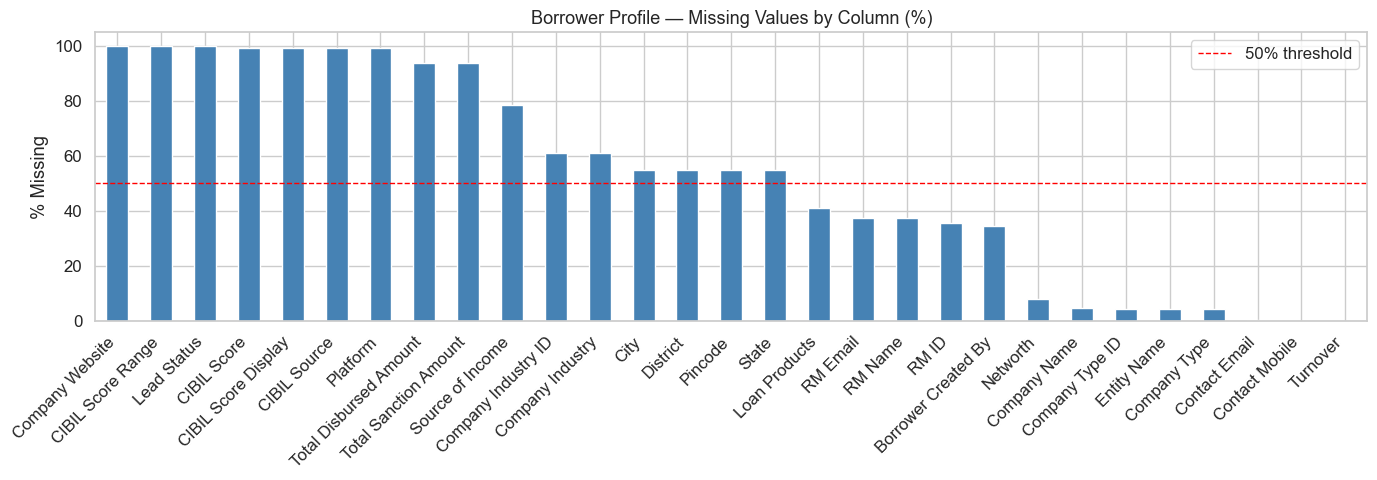

Columns > 50% missing : 16
Total borrowers       : 6,483


In [3]:
prof = data[SHEET.PROFILE]

null_pct = (prof.isnull().sum() / len(prof) * 100).sort_values(ascending=False)
null_pct = null_pct[null_pct > 0]

fig, ax = plt.subplots(figsize=(14, 5))
null_pct.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.axhline(50, color='red', linestyle='--', linewidth=1, label='50% threshold')
ax.set_title('Borrower Profile — Missing Values by Column (%)', fontsize=13)
ax.set_ylabel('% Missing')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Columns > 50% missing : {(null_pct > 50).sum()}')
print(f'Total borrowers       : {len(prof):,}')

## 3. Borrower Profile — Company Type & CIBIL

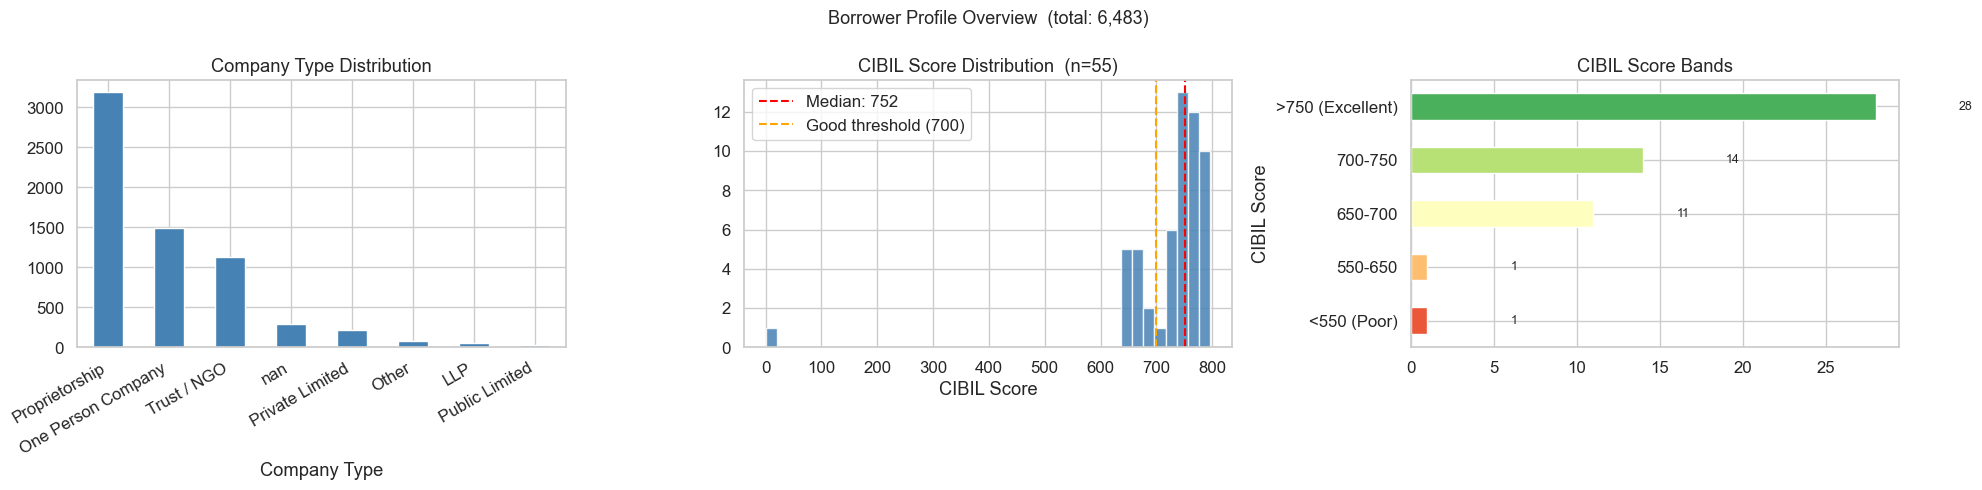

count    55.00
mean    724.22
std     108.46
min       1.00
25%     709.00
50%     752.00
75%     773.50
max     796.00
Name: CIBIL Score, dtype: float64


In [4]:
# Company type + CIBIL score side by side
ct_col = 'Company Type' if 'Company Type' in prof.columns else 'Company Type ID'
ct = prof[ct_col].value_counts(dropna=False)

cibil = prof['CIBIL Score'].dropna()
bins  = [0, 550, 650, 700, 750, 900]
band_labels = ['<550 (Poor)', '550-650', '650-700', '700-750', '>750 (Excellent)']
band_counts = pd.cut(cibil, bins=bins, labels=band_labels).value_counts().sort_index()

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

ct.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Company Type Distribution')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')

axes[1].hist(cibil, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(cibil.median(), color='red', linestyle='--', label=f'Median: {cibil.median():.0f}')
axes[1].axvline(700, color='orange', linestyle='--', label='Good threshold (700)')
axes[1].set_title(f'CIBIL Score Distribution  (n={len(cibil):,})')
axes[1].set_xlabel('CIBIL Score')
axes[1].legend()

band_counts.plot(kind='barh', ax=axes[2], color=sns.color_palette('RdYlGn', 5), edgecolor='white')
axes[2].set_title('CIBIL Score Bands')
for bar, val in zip(axes[2].patches, band_counts.values):
    axes[2].text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
                 f'{val:,}', va='center', fontsize=9)

plt.suptitle(f'Borrower Profile Overview  (total: {len(prof):,})', fontsize=13)
plt.tight_layout()
plt.show()
print(cibil.describe())

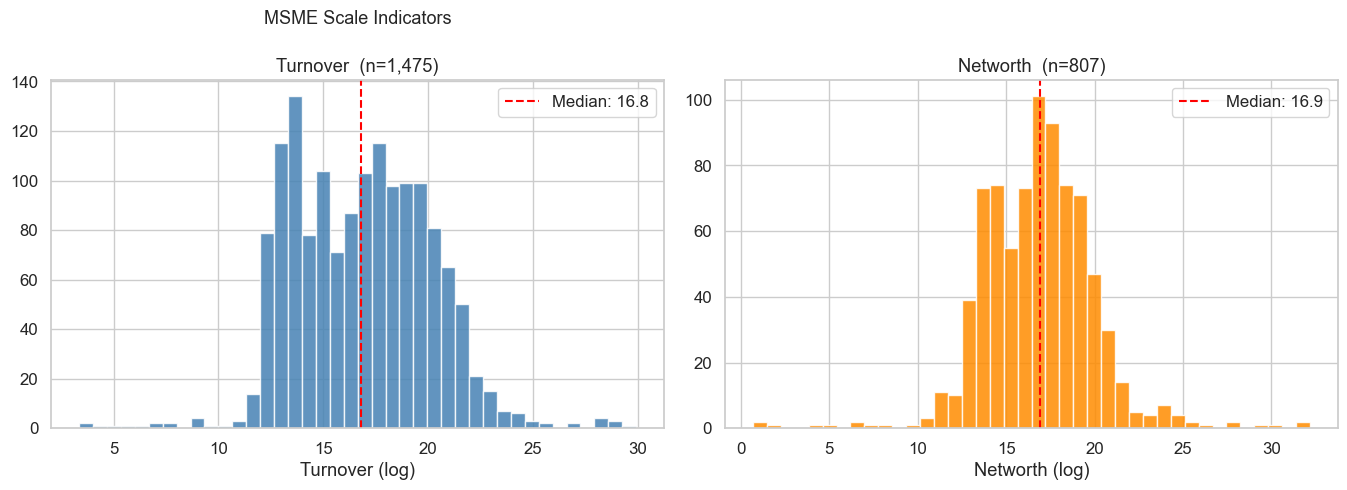

In [5]:
# Business age, turnover, networth
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, col, color, label in [
    (axes[0], 'Business Age', 'teal',        'Business Age'),
    (axes[1], 'Turnover',     'steelblue',   'Turnover (log)'),
    (axes[2], 'Networth',     'darkorange',  'Networth (log)'),
]:
    if col not in prof.columns:
        ax.set_visible(False)
        continue
    vals = prof[col].dropna()
    vals = pd.to_numeric(vals, errors='coerce').dropna()
    if col in ('Turnover', 'Networth'):
        vals = np.log1p(vals[vals > 0])
    ax.hist(vals, bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(vals.median(), color='red', linestyle='--', label=f'Median: {vals.median():.1f}')
    ax.set_title(f'{col}  (n={len(vals):,})')
    ax.set_xlabel(label)
    ax.legend()

plt.suptitle('MSME Scale Indicators', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Proxy Labels (until outcome data is provided)

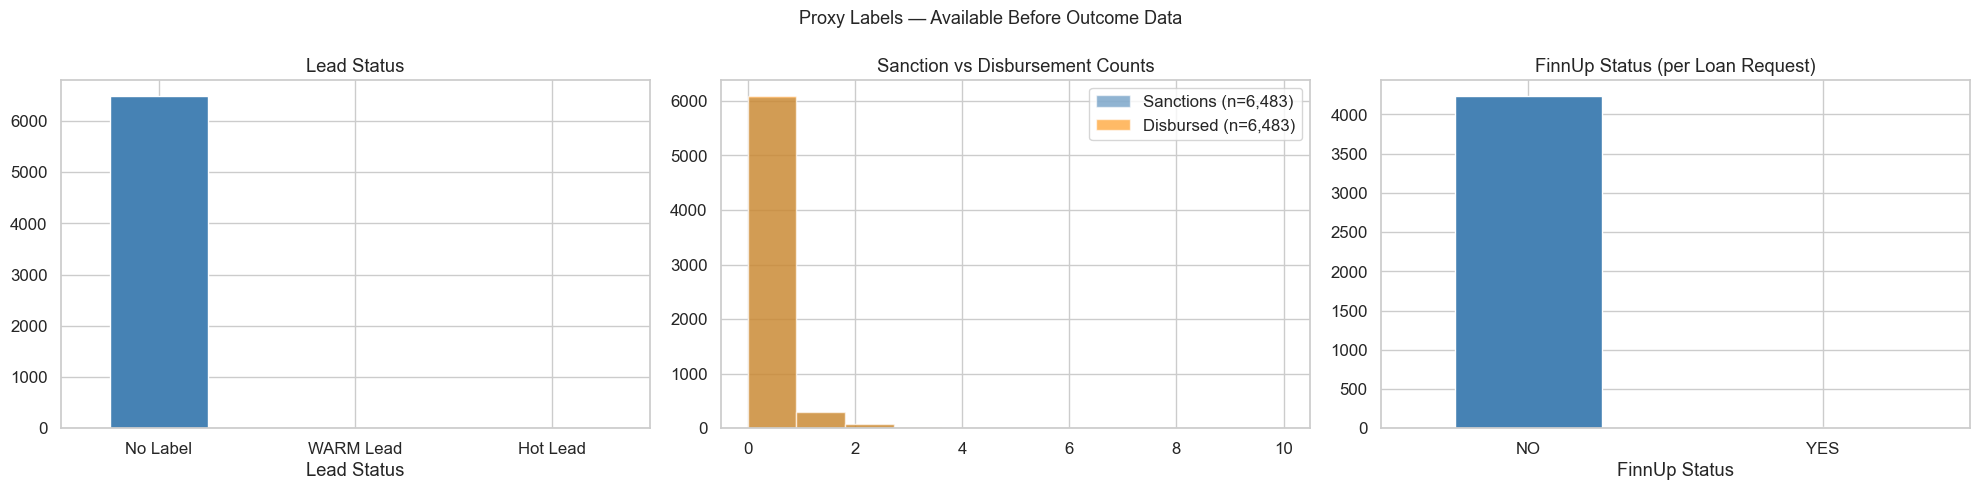

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Lead Status
if 'Lead Status' in prof.columns:
    ls = prof['Lead Status'].fillna('No Label')
    ls.value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
    axes[0].set_title('Lead Status')
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Sanction vs Disbursed count
if {'Count Sanctions', 'Count Disbursed'}.issubset(prof.columns):
    s = pd.to_numeric(prof['Count Sanctions'], errors='coerce').dropna()
    d = pd.to_numeric(prof['Count Disbursed'], errors='coerce').dropna()
    axes[1].hist(s.clip(0, 10), bins=11, alpha=0.6, label=f'Sanctions (n={len(s):,})', color='steelblue')
    axes[1].hist(d.clip(0, 10), bins=11, alpha=0.6, label=f'Disbursed (n={len(d):,})', color='darkorange')
    axes[1].set_title('Sanction vs Disbursement Counts')
    axes[1].legend()

# FinnUp Status from Loan Requests
loans = data[SHEET.LOANS]
if not loans.empty and 'FinnUp Status' in loans.columns:
    loans['FinnUp Status'].value_counts().plot(
        kind='bar', ax=axes[2], color=['steelblue', 'salmon'], edgecolor='white')
    axes[2].set_title('FinnUp Status (per Loan Request)')
    axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=0)

plt.suptitle('Proxy Labels — Available Before Outcome Data', fontsize=13)
plt.tight_layout()
plt.show()

# Funnel summary
if {'Sanction Amount', 'Disbursed Amount'}.issubset(prof.columns):
    ts = pd.to_numeric(prof['Sanction Amount'], errors='coerce').sum()
    td = pd.to_numeric(prof['Disbursed Amount'], errors='coerce').sum()
    print(f'Sanction Amount    : {ts:>15,.0f}')
    print(f'Disbursed Amount   : {td:>15,.0f}')
    print(f'Disbursement Rate  : {td/ts*100:.1f}%' if ts else 'N/A')

## 5. Bank Statements — Risk Signals

Bank rows: 3,996  |  Unique borrowers: 2,489


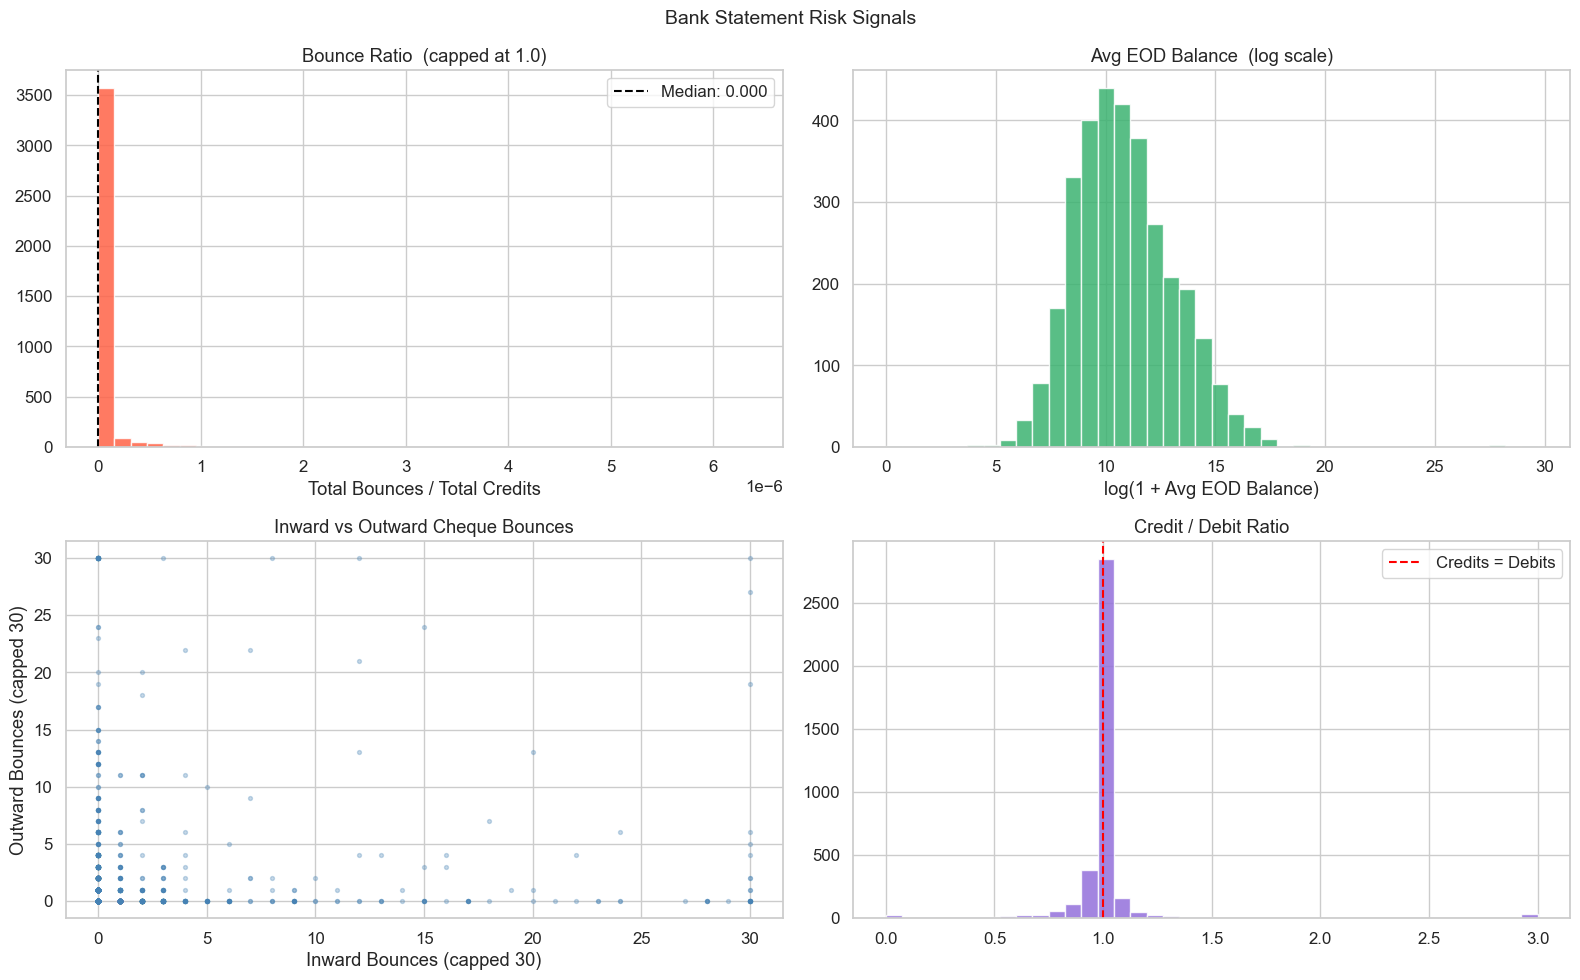

In [7]:
bank = data[SHEET.BANK]
print(f'Bank rows: {len(bank):,}  |  Unique borrowers: {bank["Borrower ID"].nunique():,}')

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Bounce ratio
br = bank['Bounce Ratio'].dropna().clip(0, 1)
axes[0, 0].hist(br, bins=40, color='tomato', edgecolor='white', alpha=0.85)
axes[0, 0].axvline(br.median(), color='black', linestyle='--', label=f'Median: {br.median():.3f}')
axes[0, 0].set_title('Bounce Ratio  (capped at 1.0)')
axes[0, 0].set_xlabel('Total Bounces / Total Credits')
axes[0, 0].legend()

# Avg EOD Balance (log)
eod = bank['Avg EOD Balance'].dropna()
eod_log = np.log1p(pd.to_numeric(eod, errors='coerce').dropna())
eod_log = eod_log[np.isfinite(eod_log)]
axes[0, 1].hist(eod_log, bins=40, color='mediumseagreen', edgecolor='white', alpha=0.85)
axes[0, 1].set_title('Avg EOD Balance  (log scale)')
axes[0, 1].set_xlabel('log(1 + Avg EOD Balance)')

# Inward vs Outward bounces
ib = pd.to_numeric(bank['Inward Cheque Bounces'], errors='coerce').clip(0, 30)
ob = pd.to_numeric(bank['Outward Cheque Bounces'], errors='coerce').clip(0, 30)
axes[1, 0].scatter(ib, ob, alpha=0.3, s=8, color='steelblue')
axes[1, 0].set_xlabel('Inward Bounces (capped 30)')
axes[1, 0].set_ylabel('Outward Bounces (capped 30)')
axes[1, 0].set_title('Inward vs Outward Cheque Bounces')

# Credit / Debit ratio
cdr = bank['Credit Debit Ratio'].dropna().clip(0, 3)
axes[1, 1].hist(cdr, bins=40, color='mediumpurple', edgecolor='white', alpha=0.85)
axes[1, 1].axvline(1.0, color='red', linestyle='--', label='Credits = Debits')
axes[1, 1].set_title('Credit / Debit Ratio')
axes[1, 1].legend()

plt.suptitle('Bank Statement Risk Signals', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Directors — CIBIL & Ownership

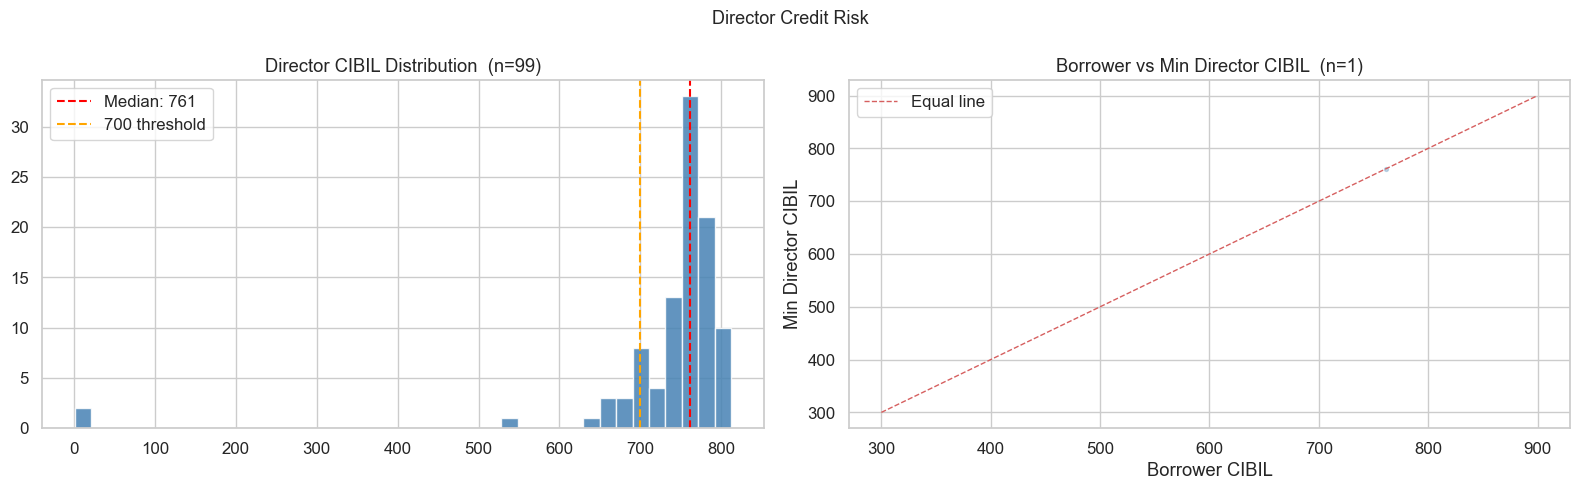

In [8]:
dirs = data[SHEET.DIRECTORS]
dir_sum = get_director_summary(data)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Director CIBIL distribution
dcibil = dirs['CIBIL Score'].dropna()
axes[0].hist(dcibil, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(dcibil.median(), color='red', linestyle='--', label=f'Median: {dcibil.median():.0f}')
axes[0].axvline(700, color='orange', linestyle='--', label='700 threshold')
axes[0].set_title(f'Director CIBIL Distribution  (n={len(dcibil):,})')
axes[0].legend()

# Borrower CIBIL vs Min Director CIBIL
m = prof[['Borrower ID', 'CIBIL Score']].merge(
    dir_sum[['Borrower ID', 'min_director_cibil']], on='Borrower ID', how='inner').dropna()
axes[1].scatter(m['CIBIL Score'], m['min_director_cibil'], alpha=0.3, s=8, color='steelblue')
axes[1].plot([300, 900], [300, 900], 'r--', linewidth=1, label='Equal line')
axes[1].set_xlabel('Borrower CIBIL')
axes[1].set_ylabel('Min Director CIBIL')
axes[1].set_title(f'Borrower vs Min Director CIBIL  (n={len(m):,})')
axes[1].legend()

plt.suptitle('Director Credit Risk', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Geographic Distribution

Unique states: 28 | Coverage: 2,926/6,483


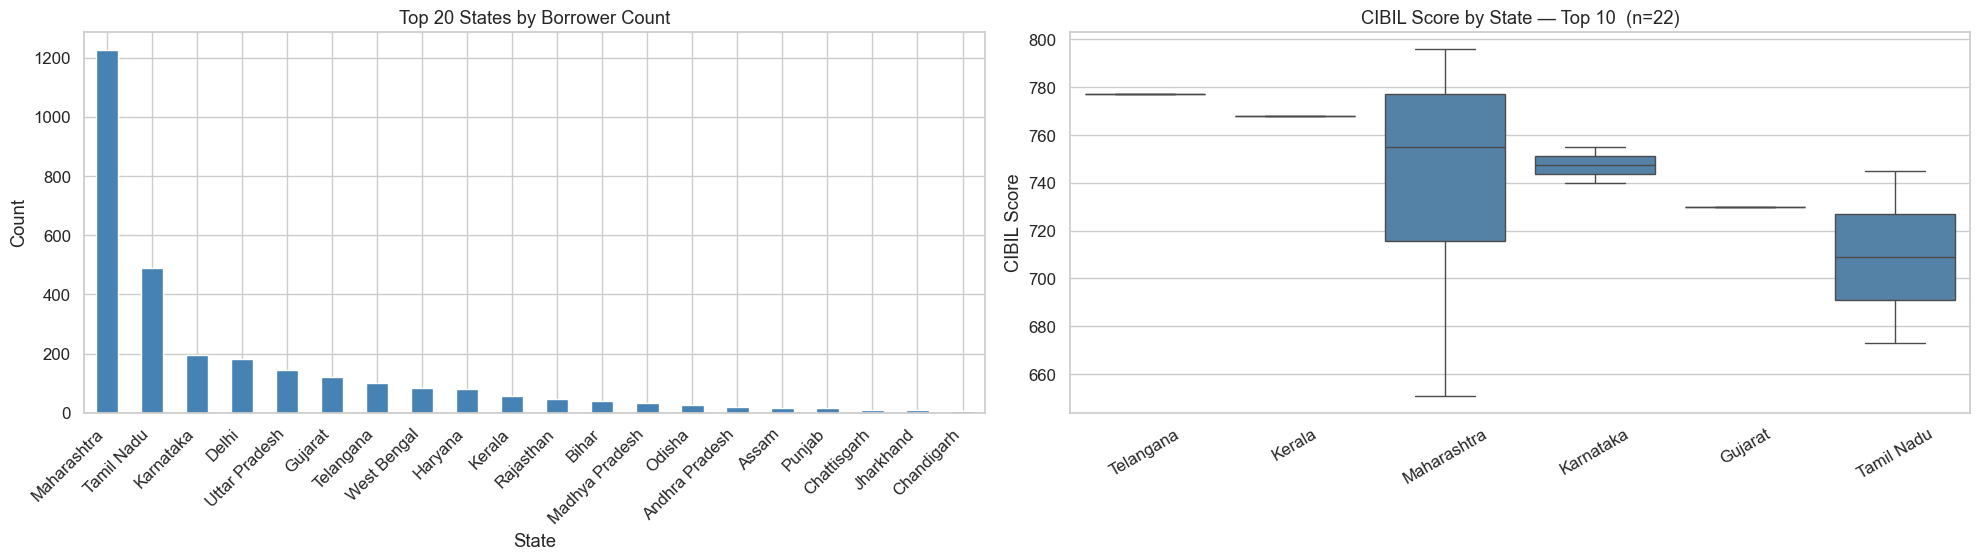

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

if 'State' in prof.columns:
    sc = prof['State'].value_counts(dropna=True).head(20)
    sc.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
    axes[0].set_title('Top 20 States by Borrower Count')
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
    axes[0].set_ylabel('Count')
    print(f'Unique states: {prof["State"].nunique()} | Coverage: {prof["State"].notna().sum():,}/{len(prof):,}')

    # Median CIBIL by top 10 states
    top10 = prof['State'].value_counts().head(10).index
    sub = prof[prof['State'].isin(top10)][['State', 'CIBIL Score']].dropna()
    if not sub.empty:
        order = sub.groupby('State')['CIBIL Score'].median().sort_values(ascending=False).index.tolist()
        sns.boxplot(data=sub, x='State', y='CIBIL Score', order=order, ax=axes[1], color='steelblue')
        axes[1].set_title(f'CIBIL Score by State — Top 10  (n={len(sub):,})')
        axes[1].set_xlabel('')
        axes[1].tick_params(axis='x', rotation=30)
    else:
        axes[1].text(0.5, 0.5, 'No CIBIL data available for states', ha='center', va='center', transform=axes[1].transAxes)
        axes[1].set_title('CIBIL Score by State (no data)')
    plt.suptitle('')

plt.tight_layout()
plt.show()

## 8. Financial KPI Analysis

Borrowers with KPI data: 500


,DSCR (Avg/Min),Current Ratio,Debt Equity Ratio,Net Profit Margin (%),PBDITA Margin (%),Debt/PBITDA Ratio
count,500.00,500.00,500.00,500.00,500.00,500.00
mean,-18.67,4.47,6.21,-18.45,-11.41,3.24
std,"1,485.32",39.08,48.54,150.66,159.78,24.87
min,"-25,670.12",-15.90,-46.73,"-2,844.99","-2,799.64",-184.76
25%,0.00,1.02,0.00,-4.57,-0.64,-0.01
50%,1.68,1.40,0.81,0.82,3.82,1.25
75%,3.83,2.14,2.60,3.52,10.31,4.71
max,"19,897.52",865.75,765.93,735.96,774.10,334.69


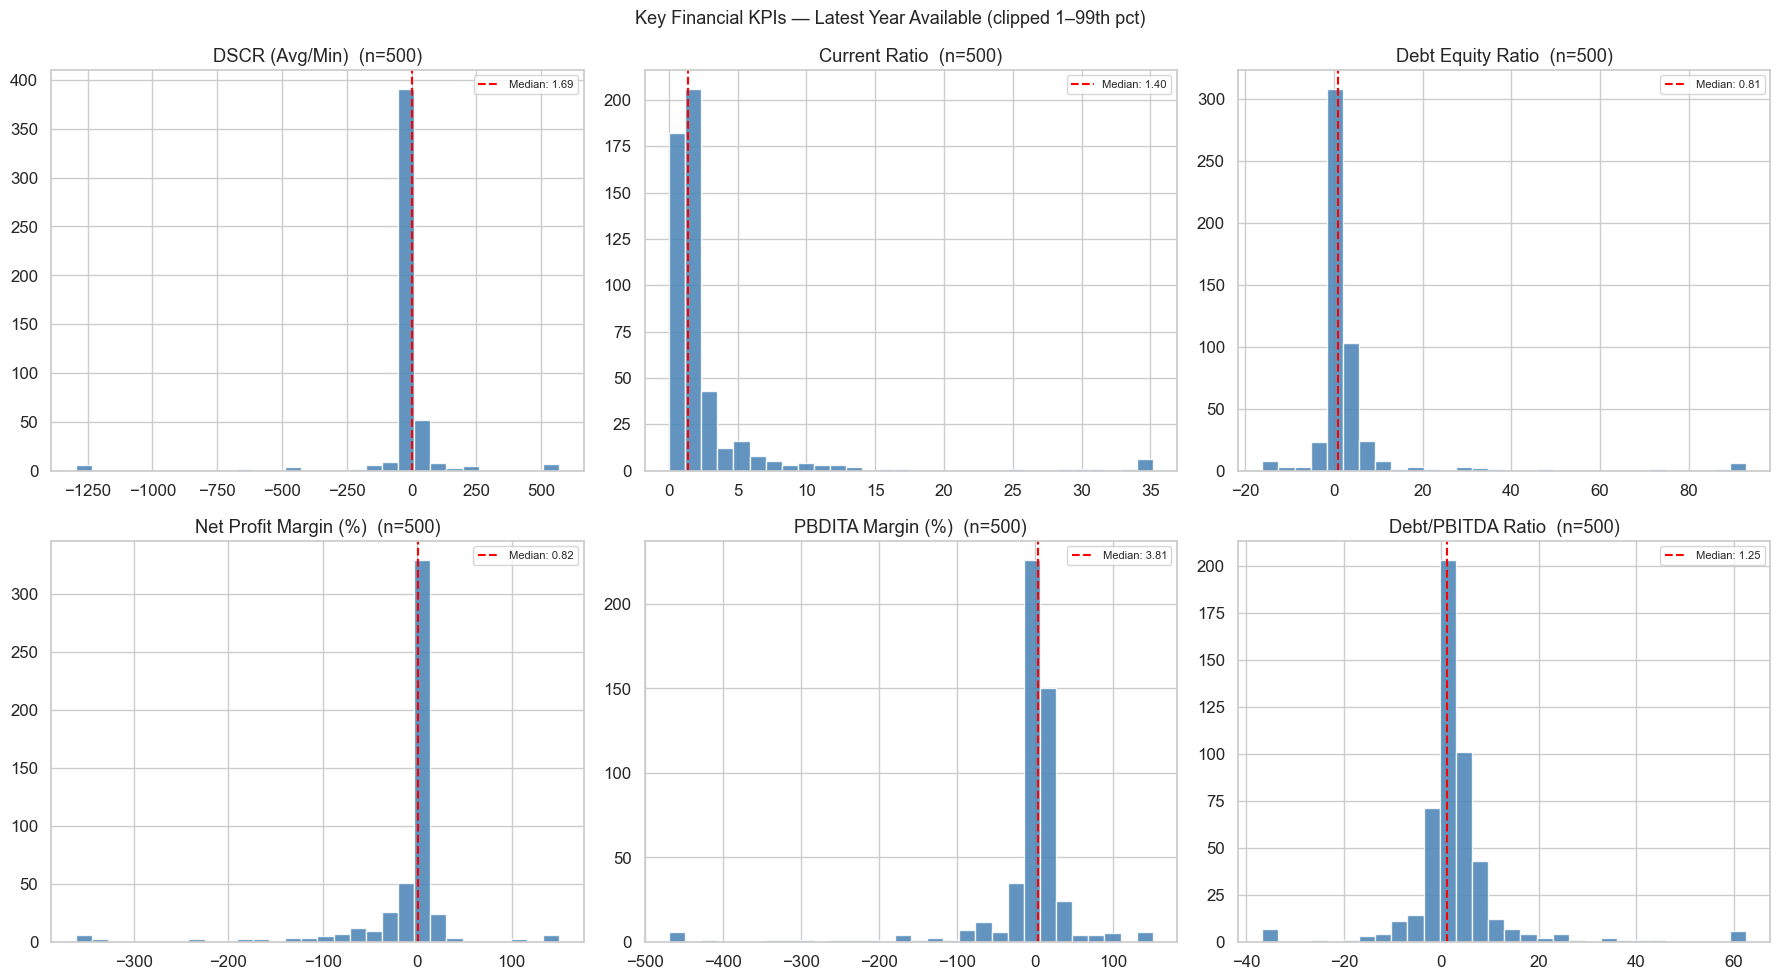

In [11]:
key_kpis = ['DSCR (Avg/Min)', 'Current Ratio', 'Debt Equity Ratio',
            'Net Profit Margin (%)', 'PBDITA Margin (%)', 'Debt/PBITDA Ratio']

kpi_pivot = get_kpi_pivot(data, kpi_labels=key_kpis, latest_year_only=True)
available = [k for k in key_kpis if k in kpi_pivot.columns]
print(f'Borrowers with KPI data: {len(kpi_pivot):,}')
display(kpi_pivot[available].describe().round(2))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, kpi in zip(axes, available):
    vals = kpi_pivot[kpi].dropna()
    p1, p99 = vals.quantile(0.01), vals.quantile(0.99)
    ax.hist(vals.clip(p1, p99), bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(vals.median(), color='red', linestyle='--', label=f'Median: {vals.median():.2f}')
    ax.set_title(f'{kpi}  (n={len(vals):,})')
    ax.legend(fontsize=8)

for ax in axes[len(available):]:
    ax.set_visible(False)

plt.suptitle('Key Financial KPIs — Latest Year Available (clipped 1–99th pct)', fontsize=13)
plt.tight_layout()
plt.show()

## 9. Loan Products

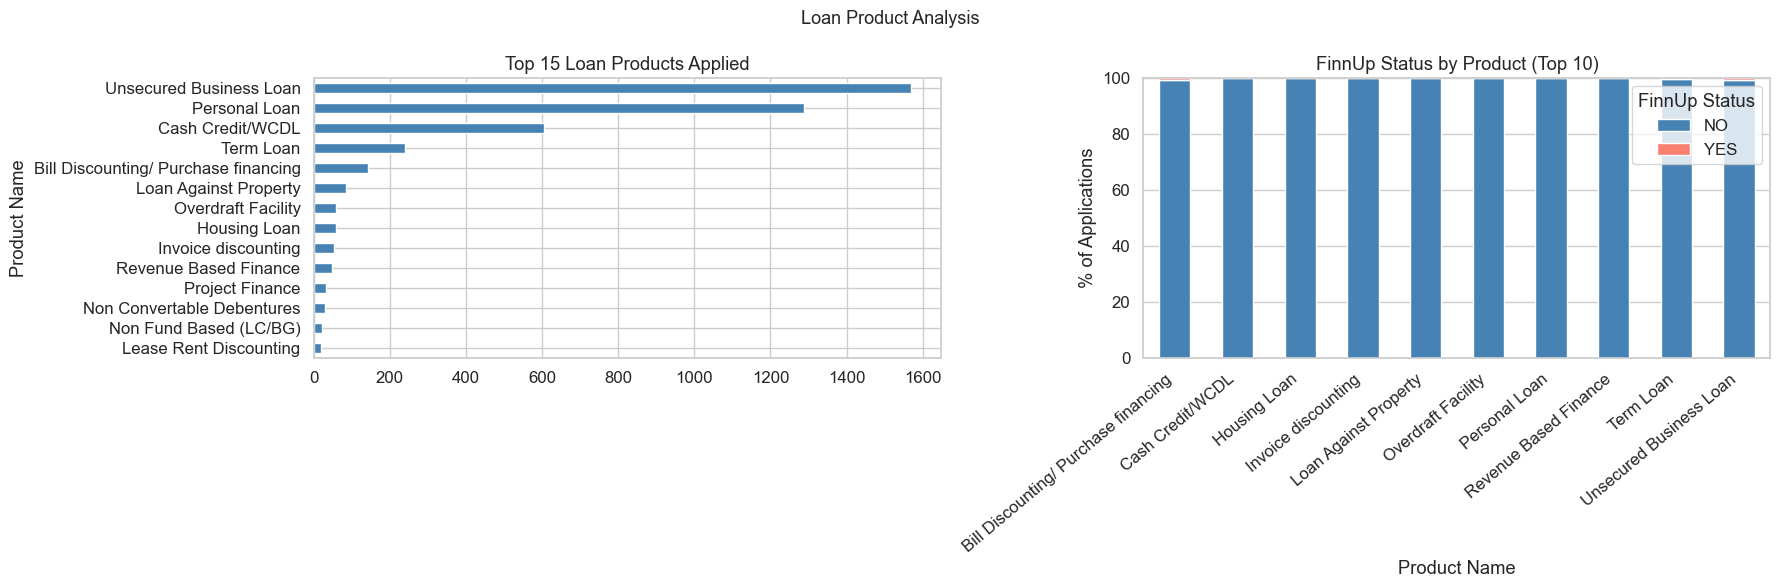

In [12]:
loans = data[SHEET.LOANS]

if not loans.empty:
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    if 'Product Name' in loans.columns:
        loans['Product Name'].value_counts().head(15).plot(
            kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
        axes[0].set_title('Top 15 Loan Products Applied')
        axes[0].invert_yaxis()

    if {'Product Name', 'FinnUp Status'}.issubset(loans.columns):
        top10 = loans['Product Name'].value_counts().head(10).index
        ct = pd.crosstab(loans[loans['Product Name'].isin(top10)]['Product Name'],
                         loans['FinnUp Status'], normalize='index') * 100
        ct.plot(kind='bar', stacked=True, ax=axes[1], edgecolor='white',
                color=['steelblue', 'salmon'])
        axes[1].set_title('FinnUp Status by Product (Top 10)')
        axes[1].set_ylabel('% of Applications')
        axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=40, ha='right')
        axes[1].legend(title='FinnUp Status')

    plt.suptitle('Loan Product Analysis', fontsize=13)
    plt.tight_layout()
    plt.show()

## 10. Correlation Heatmap — Numeric Features

Master frame: 6,483 rows  x  72 columns
Columns with >500 non-null values for correlation: 25


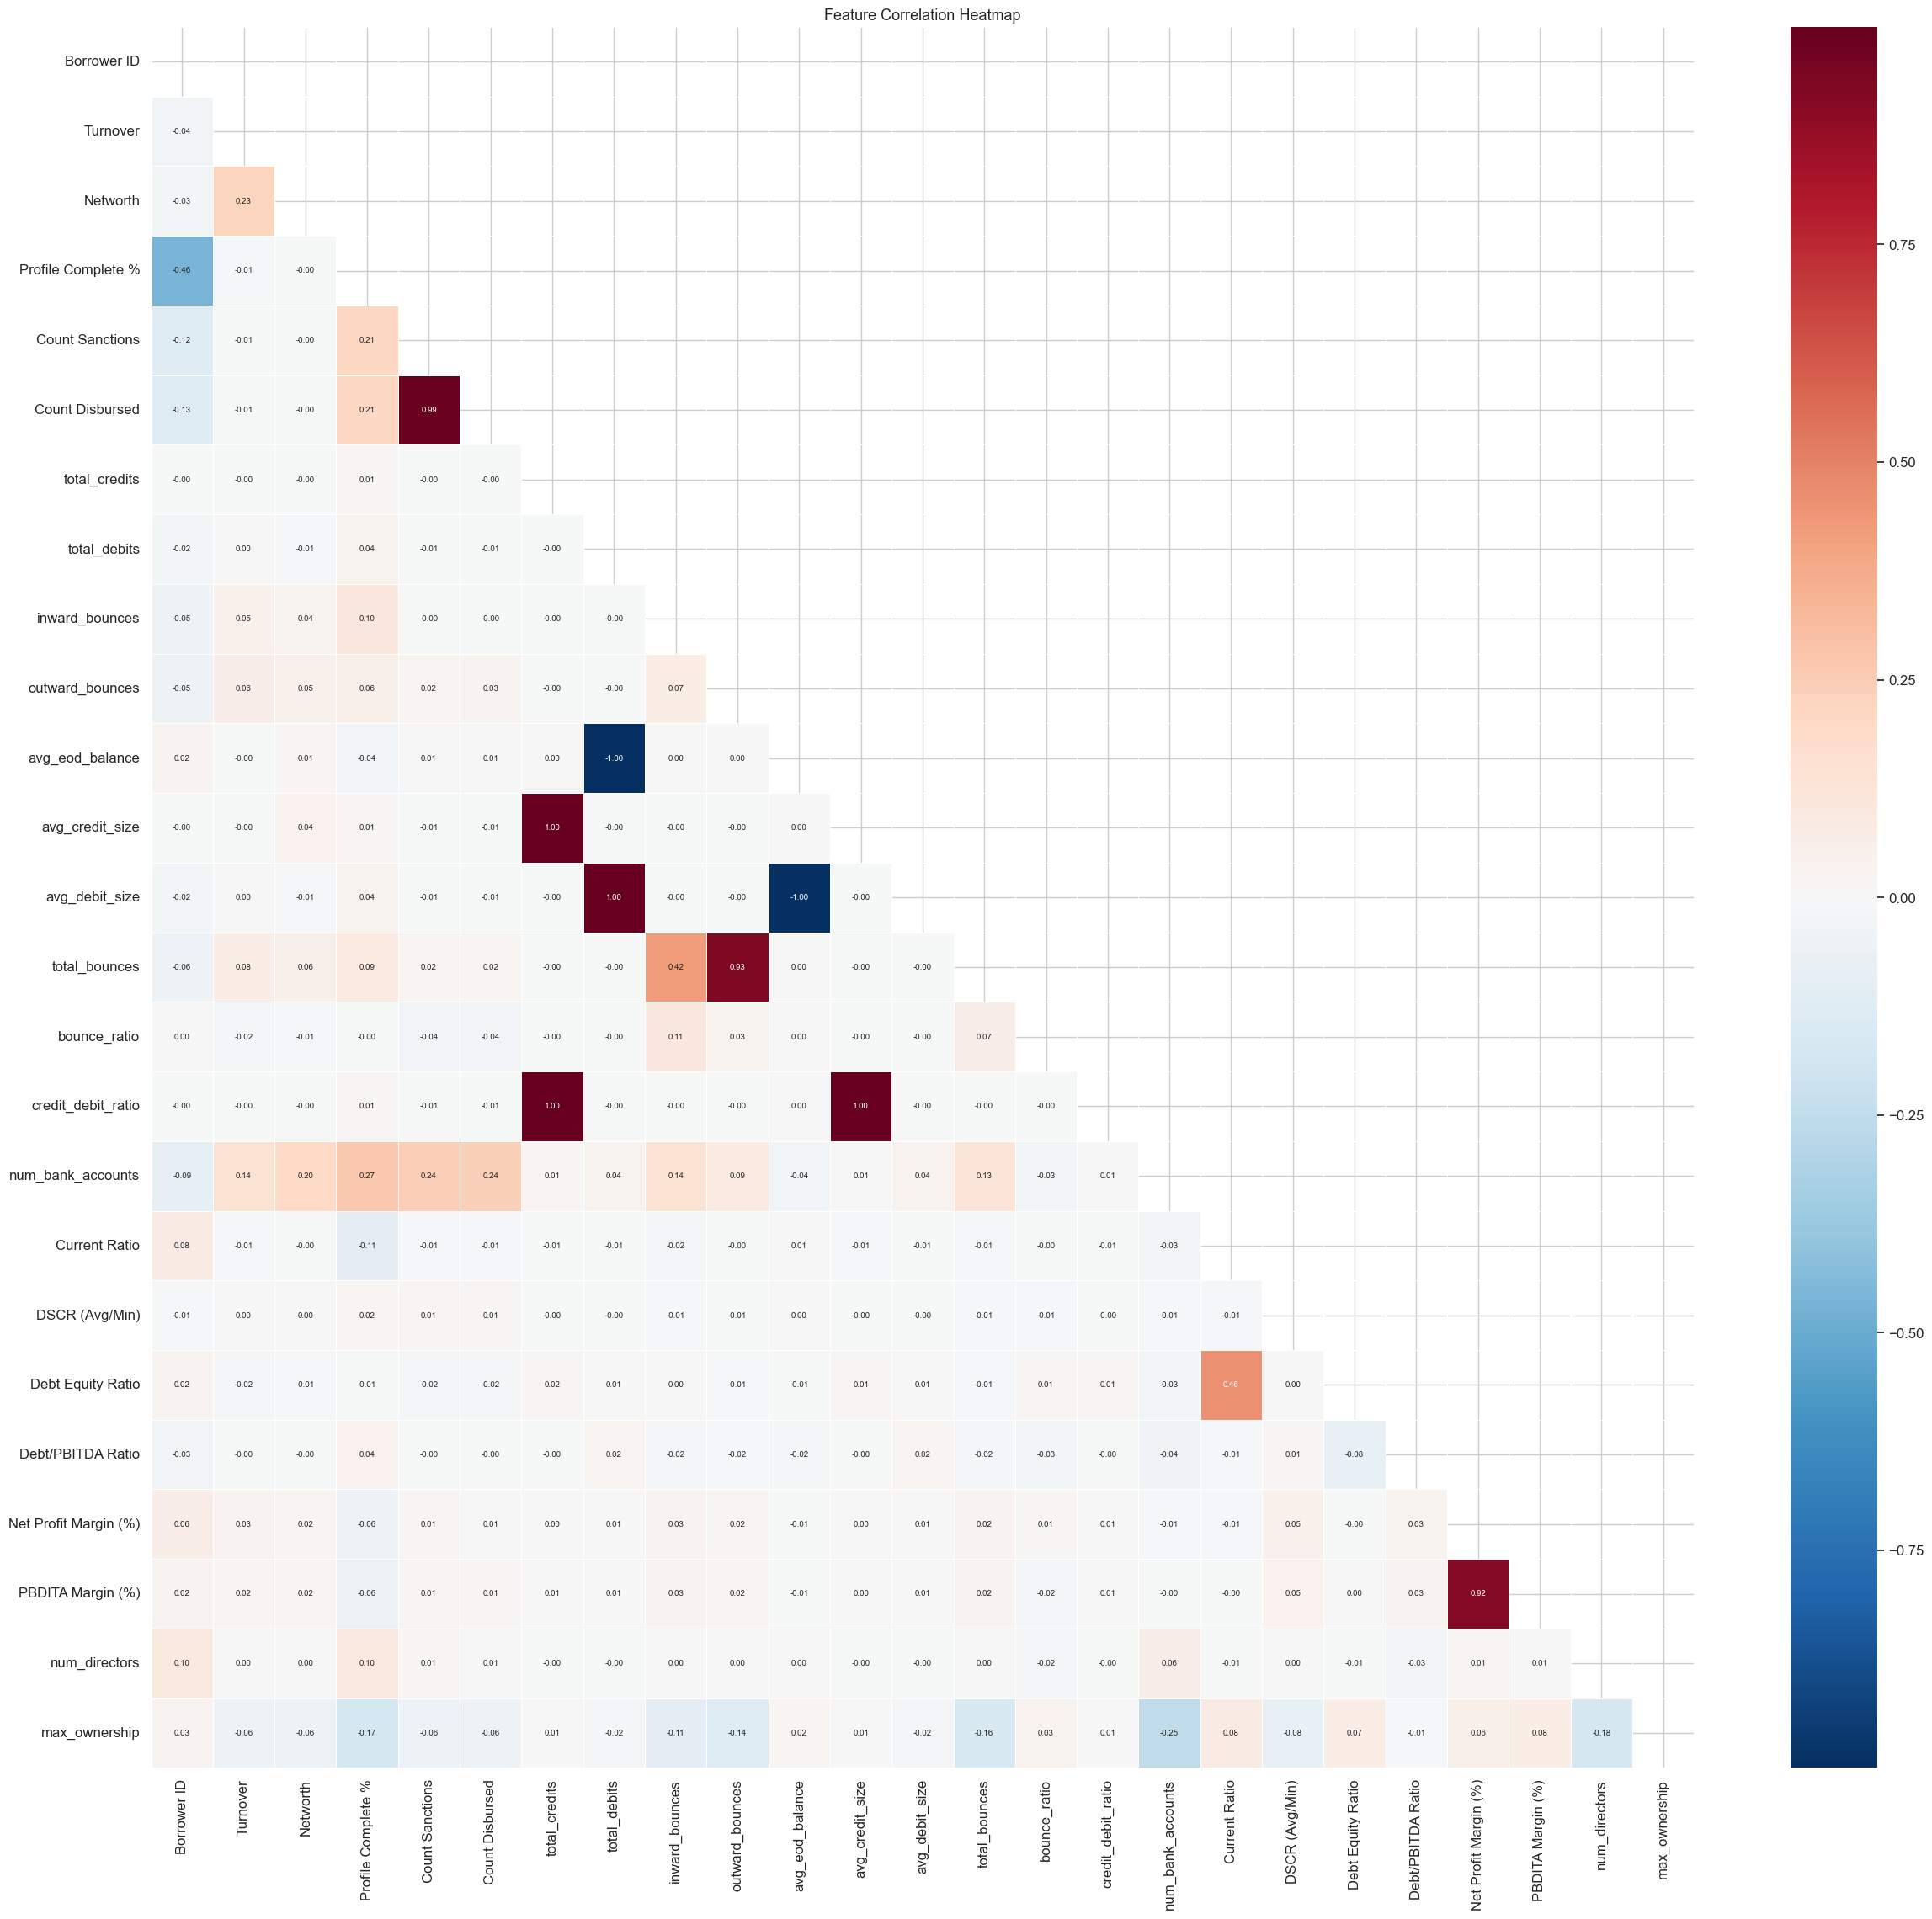

In [13]:
master = get_profile_with_bank(data)

# Merge KPIs
kpi_all = get_kpi_pivot(data, kpi_labels=key_kpis, latest_year_only=True)
if not kpi_all.empty:
    master = master.merge(kpi_all, on='Borrower ID', how='left')

# Merge director summary
dir_sum2 = get_director_summary(data)
if not dir_sum2.empty:
    master = master.merge(dir_sum2, on='Borrower ID', how='left')

print(f'Master frame: {len(master):,} rows  x  {len(master.columns)} columns')

num_cols = master.select_dtypes(include=[np.number]).columns
corr_cols = [c for c in num_cols if master[c].notna().sum() > 500]
print(f'Columns with >500 non-null values for correlation: {len(corr_cols)}')

corr = master[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(max(12, len(corr_cols)), max(10, len(corr_cols) - 2)))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, annot_kws={'size': 7}, ax=ax)
ax.set_title('Feature Correlation Heatmap', fontsize=13)
plt.tight_layout()
plt.show()

if 'CIBIL Score' in corr.columns:
    print('\nTop correlations with CIBIL Score:')
    print(corr['CIBIL Score'].drop('CIBIL Score').sort_values(key=abs, ascending=False).head(10))

## 11. Data Quality Summary for ML

In [15]:
def _col_coverage(df, col):
    """Return count of non-null numeric values for a column (0 if missing)."""
    if col not in df.columns:
        return 0
    return pd.to_numeric(df[col], errors='coerce').notna().sum()

total = len(prof)

feature_groups = {
    'CIBIL Score (borrower)':     _col_coverage(prof, 'CIBIL Score'),
    'Turnover':                    _col_coverage(prof, 'Turnover'),
    'Networth':                    _col_coverage(prof, 'Networth'),
    'Business Age':               _col_coverage(prof, 'Business Age'),
    'State / Location':            prof['State'].notna().sum() if 'State' in prof.columns else 0,
    'Bank Account Data':           data[SHEET.BANK]['Borrower ID'].nunique() if not data[SHEET.BANK].empty else 0,
    'Director CIBIL':              data[SHEET.DIRECTORS]['Borrower ID'].nunique() if not data[SHEET.DIRECTORS].empty else 0,
    'Financial KPIs':              data[SHEET.FIN_KPI]['Borrower ID'].nunique() if not data[SHEET.FIN_KPI].empty else 0,
    'Lead Status (proxy label)':   prof['Lead Status'].notna().sum() if 'Lead Status' in prof.columns else 0,
    'Count Disbursed > 0':        (_col_coverage(prof, 'Count Disbursed') and
                                   (pd.to_numeric(prof['Count Disbursed'], errors='coerce') > 0).sum()),
}

print('=' * 65)
print('DATA QUALITY SUMMARY FOR ML')
print('=' * 65)
print(f'{"Feature Group":<35} {"Count":>8}  {"Coverage":>8}  {"Bar"}')
print('-' * 65)
for name, count in feature_groups.items():
    pct = count / total * 100
    bar = '#' * int(pct / 4)
    print(f'{name:<35} {count:>8,}  {pct:>7.1f}%  {bar}')

print('=' * 65)
print(f'\nTotal borrowers: {total:,}')
print()
print('NEXT STEPS:')
print('  1. Share outcome labels  → run 02_feature_engineering.ipynb')
print('  2. Share lender policies → run 03_model_training.ipynb')


DATA QUALITY SUMMARY FOR ML
Feature Group                          Count  Coverage  Bar
-----------------------------------------------------------------
CIBIL Score (borrower)                    55      0.8%  
Turnover                               6,482    100.0%  ########################
Networth                               5,964     92.0%  ######################
Business Age                               0      0.0%  
State / Location                       2,926     45.1%  ###########
Bank Account Data                      2,489     38.4%  #########
Director CIBIL                         5,600     86.4%  #####################
Financial KPIs                           500      7.7%  #
Lead Status (proxy label)                  3      0.0%  
Count Disbursed > 0                      399      6.2%  #

Total borrowers: 6,483

NEXT STEPS:
  1. Share outcome labels  → run 02_feature_engineering.ipynb
  2. Share lender policies → run 03_model_training.ipynb


---
## Part 2 — Capstone_Consol Sheet_22.05.2026 (Final Dataset)

Four tabs: **Total borrowers** · **Approved loans** · **Loan Applications** · **Lender policy**

This is the dataset used for final model training and the live Streamlit demo.


In [1]:
import sys, os, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

CONSOL = r'..\Capstone_Consol Sheet_22.05.2026.xlsx'

xl        = pd.ExcelFile(CONSOL)
borrowers = xl.parse('Total borrowers');  borrowers.columns = [c.strip() for c in borrowers.columns]
approved  = xl.parse('Approved loans');   approved.columns  = [c.strip() for c in approved.columns]
apps      = xl.parse('Loan Applications'); apps.columns     = [c.strip() for c in apps.columns]
policies  = xl.parse('Lender policy');    policies.columns  = [c.strip() for c in policies.columns]

active_pol = policies[policies['status'] == 'Active'].reset_index(drop=True)

print(f"Total borrowers   : {len(borrowers):,} rows × {borrowers.shape[1]} features")
print(f"Approved loans    : {len(approved):,} disbursed loans")
print(f"Loan Applications : {len(apps):,} application records")
print(f"Active lenders    : {len(active_pol)} (down from 55 in previous policy file)")
print(f"\nApplication status breakdown:")
print(apps['loanapplication_status'].value_counts().to_string())


Total borrowers   : 6,187 rows × 38 features
Approved loans    : 584 disbursed loans
Loan Applications : 6,735 application records
Active lenders    : 19 (down from 55 in previous policy file)

Application status breakdown:
loanapplication_status
Reject Deal             2617
Deal Sent To Lender      808
Disbursed                541
Reject Interest           90
Archive Deal              55
Deal Sanctioned           22
Partially Disbursed       22
On Hold                   16
Express Interest           8
Discussion Initiated       6
Approve Interest           2
Initiate Discussion        2


### 26. Real Approval Label Distribution


  Real labels: 1,363 borrowers | Approved: 429 (31.5%)
[target] threshold=15.00  actual approval rate=10.04%  (target=10%)


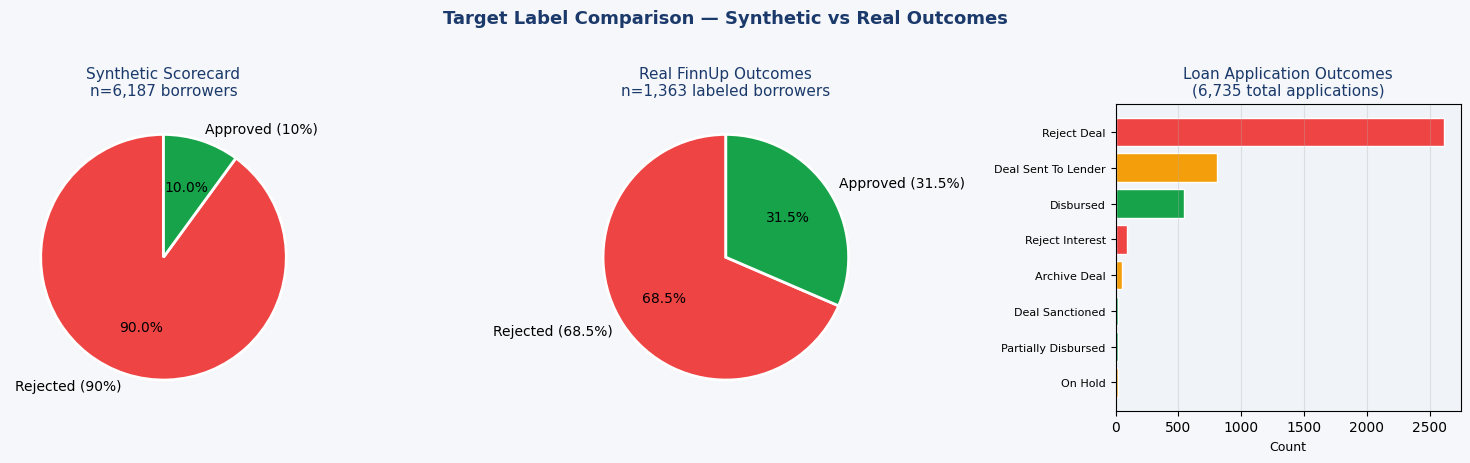


Key insight: Real approval rate is 31.5% vs 10% synthetic.
Only 1,363 of 6,187 borrowers have conclusive labels — rest excluded from training.


In [2]:
from src.features.engineering import load_raw, create_target_real, create_target

raw      = load_raw()
df_real  = create_target_real(raw)
df_syn   = create_target(raw)

NAVY  = '#1B3A6B'; TEAL  = '#0D9488'; AMBER = '#F59E0B'; RED = '#EF4444'; GREEN = '#16A34A'

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.patch.set_facecolor('#F5F7FA')
fig.suptitle('Target Label Comparison — Synthetic vs Real Outcomes', fontsize=13, fontweight='bold', color=NAVY, y=1.02)

# --- Chart 1: Synthetic label (scorecard)
labels_s = ['Rejected (90%)', 'Approved (10%)']
sizes_s  = [(df_syn['loan_approved']==0).sum(), (df_syn['loan_approved']==1).sum()]
axes[0].pie(sizes_s, labels=labels_s, colors=[RED, GREEN], autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title(f'Synthetic Scorecard\nn={len(df_syn):,} borrowers', fontsize=11, color=NAVY)

# --- Chart 2: Real labels
labels_r = ['Rejected (68.5%)', 'Approved (31.5%)']
sizes_r  = [(df_real['loan_approved']==0).sum(), (df_real['loan_approved']==1).sum()]
axes[1].pie(sizes_r, labels=labels_r, colors=[RED, GREEN], autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title(f'Real FinnUp Outcomes\nn={len(df_real):,} labeled borrowers', fontsize=11, color=NAVY)

# --- Chart 3: Application outcome funnel
status_counts = apps['loanapplication_status'].value_counts().head(8)
colors_bar = [GREEN if s in ('Disbursed','Deal Sanctioned','Partially Disbursed') else
              RED   if s in ('Reject Deal','Reject Interest') else AMBER
              for s in status_counts.index]
axes[2].barh(status_counts.index[::-1], status_counts.values[::-1], color=colors_bar[::-1], edgecolor='white')
axes[2].set_facecolor('#F0F4F8')
axes[2].set_title('Loan Application Outcomes\n(6,735 total applications)', fontsize=11, color=NAVY)
axes[2].set_xlabel('Count', fontsize=9)
axes[2].tick_params(axis='y', labelsize=8)
axes[2].grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/eda_label_comparison.png', dpi=130, bbox_inches='tight')
plt.show()
print(f"\nKey insight: Real approval rate is 31.5% vs 10% synthetic.")
print(f"Only 1,363 of 6,187 borrowers have conclusive labels — rest excluded from training.")


### 27. Active Lender Policy Comparison (55 → 19)


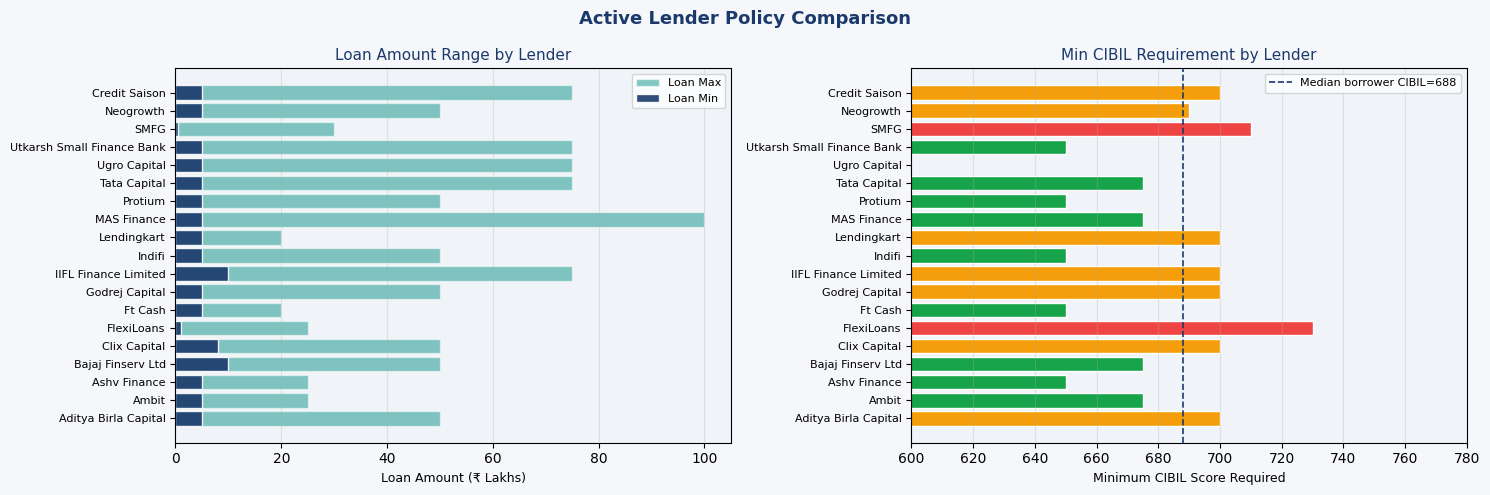


Vintage requirements:
  Aditya Birla Capital           min vintage = 12 months
  Ambit                          min vintage = 36 months
  Ashv Finance                   min vintage = 24 months
  Bajaj Finserv Ltd              min vintage = 36 months
  Clix Capital                   min vintage = 36 months
  FlexiLoans                     min vintage = 12 months
  Ft Cash                        min vintage = 18 months
  Godrej Capital                 min vintage = 24 months
  IIFL Finance Limited           min vintage = 24 months
  Indifi                         min vintage = 12 months
  Lendingkart                    min vintage = 12 months
  MAS Finance                    min vintage = 36 months
  Protium                        min vintage = 36 months
  Tata Capital                   min vintage = 36 months
  Ugro Capital                   min vintage = 24 months
  Utkarsh Small Finance Bank     min vintage = 24 months
  SMFG                           min vintage = 24 months
  Neogro

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.patch.set_facecolor('#F5F7FA')
fig.suptitle('Active Lender Policy Comparison', fontsize=13, fontweight='bold', color=NAVY)

# --- Lender loan range chart
lenders = active_pol['Lender'].tolist()
loan_min = pd.to_numeric(active_pol['Loan Amount Min'], errors='coerce').fillna(0) / 1e5
loan_max = pd.to_numeric(active_pol['Loan Amount Max'], errors='coerce').fillna(0) / 1e5

y_pos = range(len(lenders))
axes[0].barh(y_pos, loan_max, color=TEAL, alpha=0.5, label='Loan Max', edgecolor='white')
axes[0].barh(y_pos, loan_min, color=NAVY, alpha=0.9, label='Loan Min', edgecolor='white')
axes[0].set_yticks(list(y_pos))
axes[0].set_yticklabels(lenders, fontsize=8)
axes[0].set_xlabel('Loan Amount (₹ Lakhs)', fontsize=9)
axes[0].set_title('Loan Amount Range by Lender', fontsize=11, color=NAVY)
axes[0].set_facecolor('#F0F4F8')
axes[0].legend(fontsize=8)
axes[0].grid(True, axis='x', alpha=0.3)

# --- CIBIL min bar
cibil_min = pd.to_numeric(active_pol['CIBIL Score'], errors='coerce').fillna(0)
colors_c  = [GREEN if v <= 680 else AMBER if v <= 700 else RED for v in cibil_min]
axes[1].barh(list(y_pos), cibil_min, color=colors_c, edgecolor='white')
axes[1].set_yticks(list(y_pos))
axes[1].set_yticklabels(lenders, fontsize=8)
axes[1].set_xlabel('Minimum CIBIL Score Required', fontsize=9)
axes[1].set_title('Min CIBIL Requirement by Lender', fontsize=11, color=NAVY)
axes[1].set_facecolor('#F0F4F8')
axes[1].axvline(688, color=NAVY, linestyle='--', linewidth=1.2, label=f'Median borrower CIBIL=688')
axes[1].legend(fontsize=8)
axes[1].grid(True, axis='x', alpha=0.3)
axes[1].set_xlim(600, 780)

plt.tight_layout()
plt.savefig('../outputs/eda_lender_policy.png', dpi=130, bbox_inches='tight')
plt.show()

print("\nVintage requirements:")
for _, row in active_pol[['Lender','Vintage (in months)']].iterrows():
    print(f"  {row['Lender']:<30} min vintage = {row['Vintage (in months)']} months")


### 28. Model Performance — Synthetic vs Real Labels


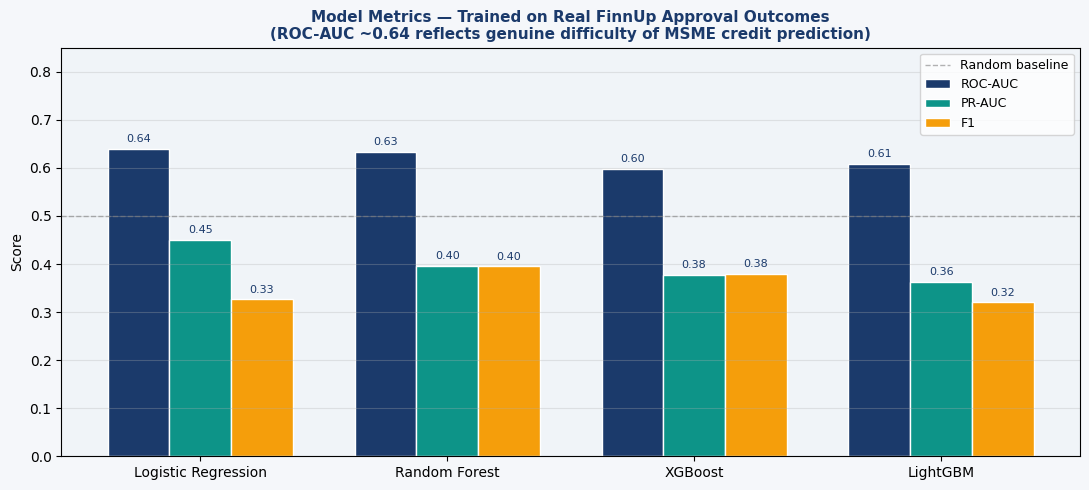


Note: Previous synthetic-label models showed ROC-AUC ~0.97 — artificially high because
the scorecard rules were directly predictable. Real data at 0.64 is more credible.


In [4]:
import json
metrics_path = '../outputs/models/metrics.json'
with open(metrics_path) as f:
    metrics = json.load(f)

models  = [m['model'] for m in metrics]
roc_auc = [m['roc_auc'] for m in metrics]
pr_auc  = [m['pr_auc']  for m in metrics]
f1      = [m['f1']      for m in metrics]

x = np.arange(len(models))
w = 0.25

fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor('#F5F7FA')
ax.set_facecolor('#F0F4F8')

b1 = ax.bar(x - w,   roc_auc, w, label='ROC-AUC', color=NAVY,  edgecolor='white')
b2 = ax.bar(x,       pr_auc,  w, label='PR-AUC',  color=TEAL,  edgecolor='white')
b3 = ax.bar(x + w,   f1,      w, label='F1',       color=AMBER, edgecolor='white')

ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.6, label='Random baseline')
ax.set_xticks(x); ax.set_xticklabels(models, fontsize=10)
ax.set_ylim(0, 0.85)
ax.set_ylabel('Score', fontsize=10)
ax.set_title('Model Metrics — Trained on Real FinnUp Approval Outcomes\n'
             '(ROC-AUC ~0.64 reflects genuine difficulty of MSME credit prediction)',
             fontsize=11, fontweight='bold', color=NAVY)
ax.legend(fontsize=9)
ax.grid(True, axis='y', alpha=0.3)

for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8, color=NAVY)

plt.tight_layout()
plt.savefig('../outputs/eda_model_comparison.png', dpi=130, bbox_inches='tight')
plt.show()

print("\nNote: Previous synthetic-label models showed ROC-AUC ~0.97 — artificially high because")
print("the scorecard rules were directly predictable. Real data at 0.64 is more credible.")
